In [45]:
#Importing neccessary libraries
import pandas as pd
#loading file
file_path5 = r"C:\Users\HP\Downloads\student-scores.csv"
df = pd.read_csv(file_path5, on_bad_lines = "skip")
#handling white spaces
#df.columns = df.columns.str.strip()
#displaying the first 10 rows of data
print(df.head(10))
#displaying the column names and data types
print(df.info())

   id first_name  last_name                                  email  gender  \
0   1       Paul      Casey         paul.casey.1@gslingacademy.com    male   
1   2   Danielle   Sandoval  danielle.sandoval.2@gslingacademy.com  female   
2   3       Tina    Andrews       tina.andrews.3@gslingacademy.com  female   
3   4       Tara      Clark         tara.clark.4@gslingacademy.com  female   
4   5    Anthony     Campos     anthony.campos.5@gslingacademy.com    male   
5   6      Kelly       Wade         kelly.wade.6@gslingacademy.com  female   
6   7    Anthony      Smith      anthony.smith.7@gslingacademy.com    male   
7   8     George      Short       george.short.8@gslingacademy.com    male   
8   9    Stanley  Gutierrez  stanley.gutierrez.9@gslingacademy.com    male   
9  10     Audrey    Simpson    audrey.simpson.10@gslingacademy.com  female   

   part_time_job  absence_days  extracurricular_activities  \
0          False             3                       False   
1          False 

Data Preprocessing and Cleaning

In [46]:
#checking for missing values
print(df.isnull().sum())
#checking for duplicate values
print("Duplicate Rows:", df.duplicated().sum())
#Checking that the data types are correct
print(df.dtypes)


id                            0
first_name                    0
last_name                     0
email                         0
gender                        0
part_time_job                 0
absence_days                  0
extracurricular_activities    0
weekly_self_study_hours       0
career_aspiration             0
math_score                    0
history_score                 0
physics_score                 0
chemistry_score               0
biology_score                 0
english_score                 0
geography_score               0
dtype: int64
Duplicate Rows: 0
id                             int64
first_name                    object
last_name                     object
email                         object
gender                        object
part_time_job                   bool
absence_days                   int64
extracurricular_activities      bool
weekly_self_study_hours        int64
career_aspiration             object
math_score                     int64
history_score     

In [47]:
#converting gender & career aspiration to categorical data types
df["gender"] = df["gender"].astype("category")
df["career_aspiration"] = df["career_aspiration"].astype("category")
df.dtypes

id                               int64
first_name                      object
last_name                       object
email                           object
gender                        category
part_time_job                     bool
absence_days                     int64
extracurricular_activities        bool
weekly_self_study_hours          int64
career_aspiration             category
math_score                       int64
history_score                    int64
physics_score                    int64
chemistry_score                  int64
biology_score                    int64
english_score                    int64
geography_score                  int64
dtype: object

Exploratory Data Analysis (EDA)

In [48]:
#calculating overall academic success for further analysis(feature engineering)
# List of subject score columns
score_cols = ['math_score', 'history_score', 'physics_score', 'chemistry_score', 'biology_score', 'english_score', 'geography_score']

# Creating a new column 'overall_score' as the average of the subject scores
df['overall_score'] = df[score_cols].mean(axis=1)

# Displaying the first ten rows to verify
print(df[['overall_score']].head(10))


   overall_score
0      82.000000
1      91.428571
2      86.428571
3      78.714286
4      74.428571
5      82.000000
6      84.714286
7      82.000000
8      81.142857
9      76.714286


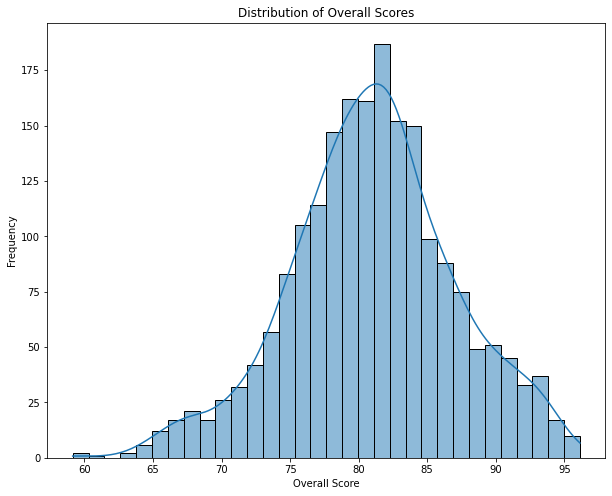

In [49]:
#Exploring the distribution of the overall scores
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,8))
sns.histplot(df['overall_score'], kde=True)
plt.title('Distribution of Overall Scores')
plt.xlabel('Overall Score')
plt.ylabel('Frequency')
plt.show()


Observation: The histogram is showing a bell-shaped distribution which suggests that the majority of students cluster around an average performance, with fewer students scoring very low or very high. 

### Impact of weekly self study hours on subject scores ###

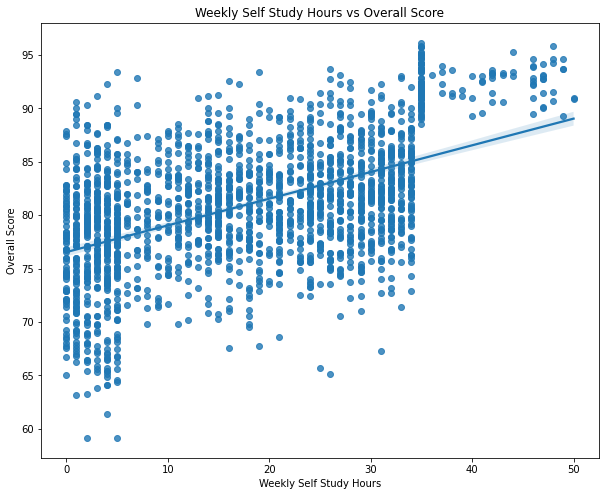

In [50]:
#Analyzing the impact of weekly self study hours on Overall SCores
plt.figure(figsize=(10,8))
sns.regplot(x='weekly_self_study_hours', y='overall_score', data=df)
plt.title('Weekly Self Study Hours vs Overall Score')
plt.xlabel('Weekly Self Study Hours')
plt.ylabel('Overall Score')
plt.show()


Observation: As weekly self-study hours increase, there is a tendency for the overall score to rise but there is a noticeable spread of scores for each level of study hours. Not all students that spend more time studying achieve the highest scores, and some low-hour students still score high. There may be individual cases where students study a lot but don’t have corresponding high scores, and vice versa. These could be outliers or might reflect other factors (e.g., part-time job, attendance, study methods).

In [51]:
#calculating the correlation between weekly self study hours and overall scores.
corr = df['weekly_self_study_hours'].corr(df['overall_score'])
print("Correlation:", corr)


Correlation: 0.5015199798379675


Observation: Medium positive correlation

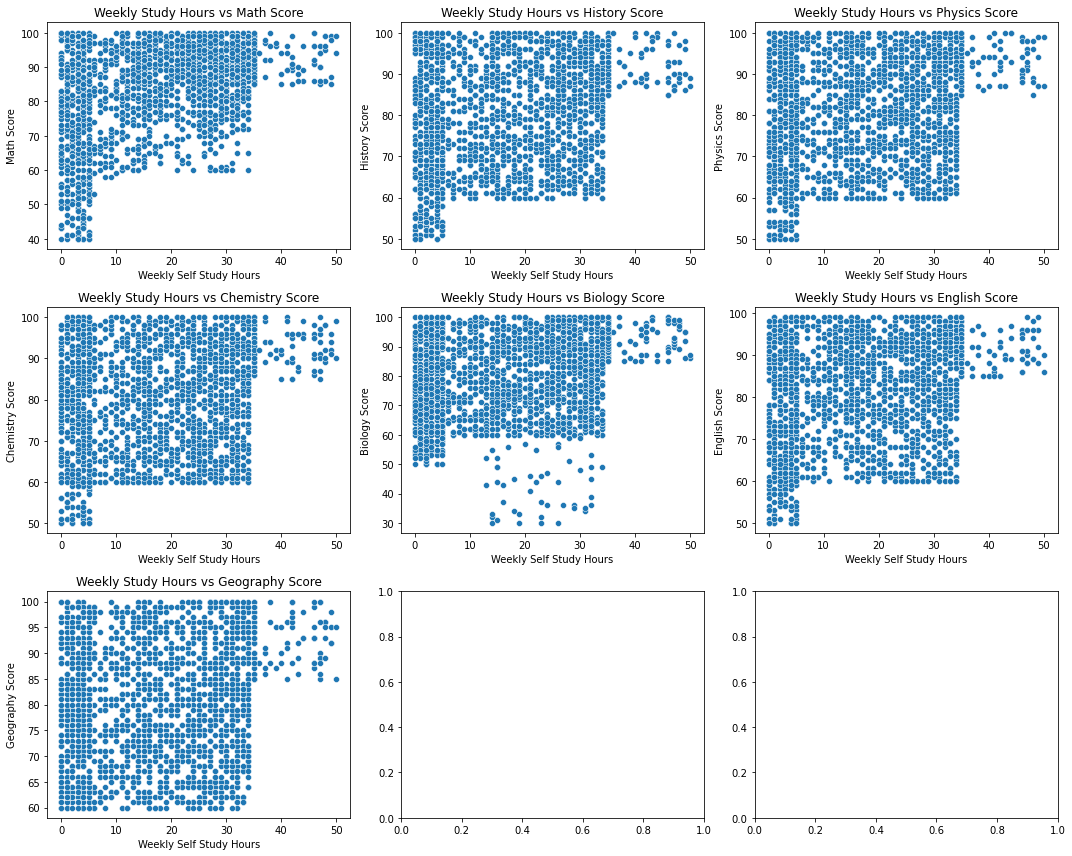

In [52]:
#first attempt, wrote the code for each of the subjects starting with maths but needed a more efficient code to compare all subjects
#plt.figure(figsize=(10,6))
#sns.scatterplot(x='weekly_self_study_hours', y='math_score', data=df)
#plt.title('Weekly Self Study Hours vs Math Score')
#plt.xlabel('Weekly Self Study Hours')
#plt.ylabel('Math Score')
#plt.show()

# #Analyzing the impact of self study hours on subjects
import matplotlib.pyplot as plt
import seaborn as sns

# List of all subject score columns
subject_scores = ['math_score', 'history_score', 'physics_score', 'chemistry_score', 
                  'biology_score', 'english_score', 'geography_score']

# Set up subplots: Create a figure with multiple subplots (arranged in 3 rows, 3 columns)
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))  # Adjust grid if needed
axes = axes.flatten()  # Flatten the 2D array of subplots into 1D for easy indexing

# Loop through each subject and create a scatter plot
for i, subject in enumerate(subject_scores):
    sns.scatterplot(x='weekly_self_study_hours', y=subject, data=df, ax=axes[i])
    axes[i].set_title(f'Weekly Study Hours vs {subject.replace("_", " ").title()}')
    axes[i].set_xlabel('Weekly Self Study Hours')
    axes[i].set_ylabel(subject.replace("_", " ").title())

# Adjust layout to prevent overlapping
plt.tight_layout()
plt.show()


Observation: As the self study hours increase, some subject scores increase but not very consistently. Many students have high scores regardless of study hours.
This could mean that some students perform well even with fewer study hours, possibly due to other factors like teaching quality, level of comprehension, or better study techniques.
Outliers exists which indicates that self study alone cannot guarantee a high score.

### Impact of parttime jobs on Student's performance ###


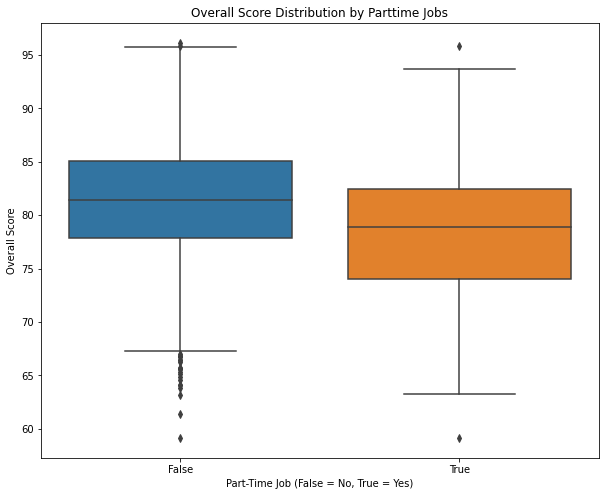

In [53]:
#Comparing the overall performances of students with part time jobs with students that do not have a parttime job
plt.figure(figsize = (10, 8))
sns.boxplot(data=df, x='part_time_job', y='overall_score')
plt.title('Overall Score Distribution by Parttime Jobs')
plt.xlabel('Part-Time Job (False = No, True = Yes)')
plt.ylabel('Overall Score')
plt.show()


Students with and without part-time jobs have a very close median overall scores, this shows that having a job may not significantly impact academic performance. Students without part-time jobs show a slightly narrower spread which indicstes more consistency in their scores, while those with part-time jobs exhibit greater variability and a few more extreme outliers. This could mean that some students successfully balance work and studies, while others struggle to maintain high performance.

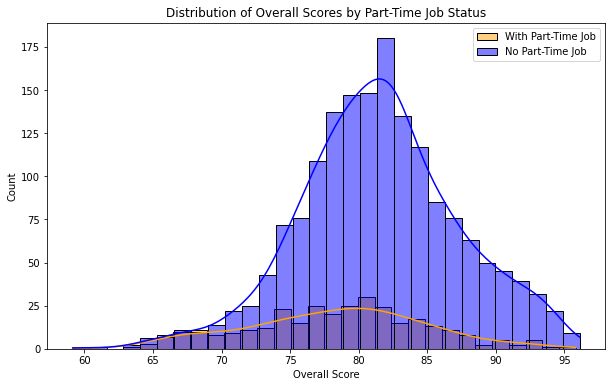

In [54]:
#using a histogram to check the distribution of scores
plt.figure(figsize=(10,6))
sns.histplot(df[df['part_time_job'] == True]['overall_score'], label='With Part-Time Job', color='orange', kde=True, bins=30)
sns.histplot(df[df['part_time_job'] == False]['overall_score'], label='No Part-Time Job', color='blue', kde=True, bins=30)
plt.title('Distribution of Overall Scores by Part-Time Job Status')
plt.xlabel('Overall Score')
plt.ylabel('Count')
plt.legend()
plt.show()


The number of students with no part time jobs that have higher overall scores are significantly higher than the number of students with part time jobs that have high scores.

### Comparing Absence Days with Overall Student Scores ###

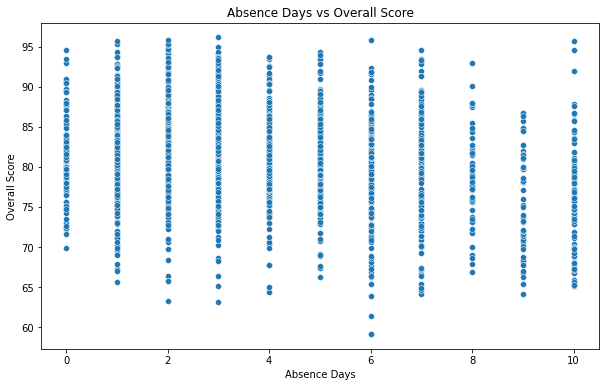

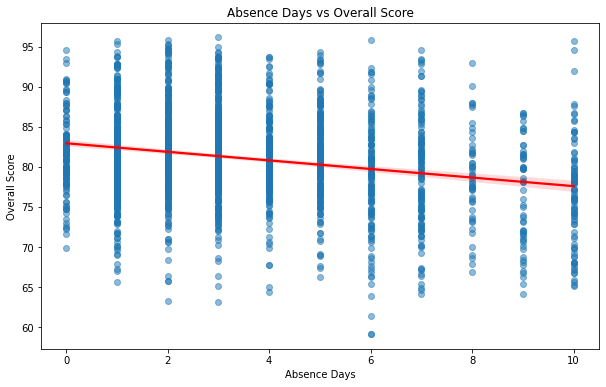

Correlation between absence days and overall score: -0.2328680352567336


In [ ]:
#Checking the relationship between Absence daysand overall score
plt.figure(figsize=(10,6))
sns.scatterplot(x='absence_days', y='overall_score', data=df)
plt.title('Absence Days vs Overall Score')
plt.xlabel('Absence Days')
plt.ylabel('Overall Score')
plt.show()


# Calculating the correlation between absence days and overall score
corr_value = df['absence_days'].corr(df['overall_score'])
print("Correlation between absence days and overall score:", corr_value)


### Impact of extra curricular activities on Student Scores ###

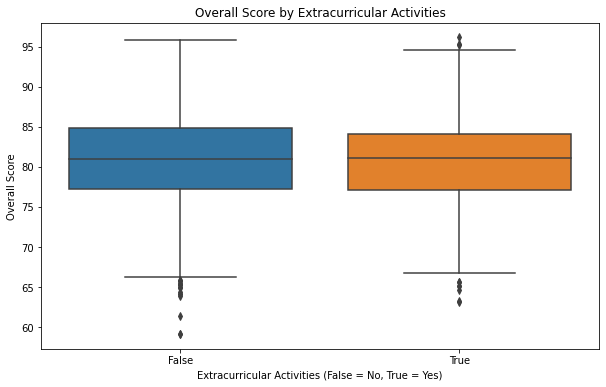

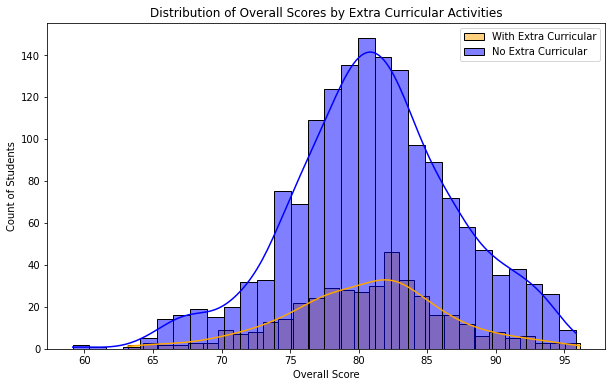

Correlation between extracurricular_activities and overall score: -0.031952152940027824


In [56]:
#Checking if extra curricular activities help or hurt student scores
plt.figure(figsize=(10,6))
sns.boxplot(x='extracurricular_activities', y='overall_score', data=df)
plt.title('Overall Score by Extracurricular Activities')
plt.xlabel('Extracurricular Activities (False = No, True = Yes)')
plt.ylabel('Overall Score')
plt.show()

#using a histogram to check the distribution of scores for students that engage in extra curricular activities vs those that do not
plt.figure(figsize=(10,6))
sns.histplot(df[df['extracurricular_activities'] == True]['overall_score'], label='With Extra Curricular', color='orange', kde=True, bins=30)
sns.histplot(df[df['extracurricular_activities'] == False]['overall_score'], label='No Extra Curricular', color='blue', kde=True, bins=30)
plt.title('Distribution of Overall Scores by Extra Curricular Activities')
plt.xlabel('Overall Score')
plt.ylabel('Count of Students')
plt.legend()
plt.show()

# Calculating the correlation between absence days and overall score
corr_value = df['extracurricular_activities'].corr(df['overall_score'])
print("Correlation between extracurricular_activities and overall score:", corr_value)


### Identifying the subject that has the strongest correlation with overall academic success


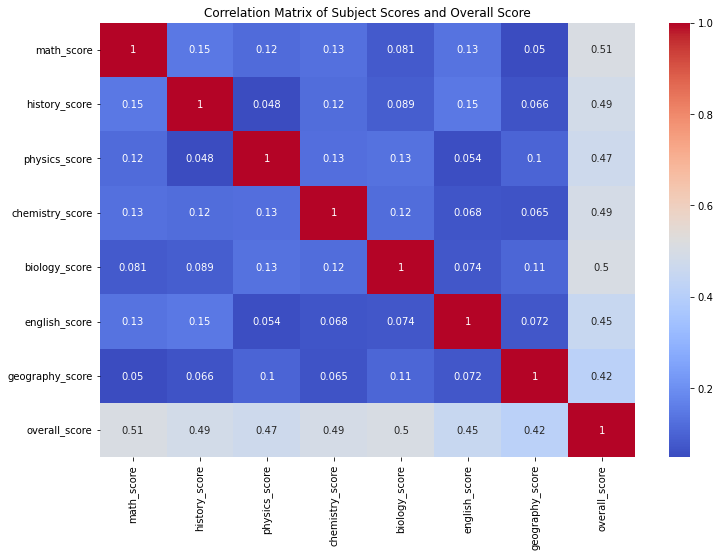

math_score         0.508116
history_score      0.486900
physics_score      0.472104
chemistry_score    0.492216
biology_score      0.502391
english_score      0.451550
geography_score    0.415929
Name: overall_score, dtype: float64


In [ ]:
plt.figure(figsize=(12,8))
corr_matrix = df[score_cols + ['overall_score']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Subject Scores and Overall Score')
plt.show()

# Selecting only the subject scores and the overall score columns
subject_columns = ['math_score', 'history_score', 'physics_score', 'chemistry_score', 
                   'biology_score', 'english_score', 'geography_score', 'overall_score']

# Calculsting the correlation matrix
correlation_matrix = df[subject_columns].corr()

# Calculating the correlation of each subject with overall score
correlation_with_overall = correlation_matrix['overall_score'].drop('overall_score')
print(correlation_with_overall)


Based on the results, mathematics has the strongest correllation with the overall score with 0.508

### Factors that influence academic success ###

In [59]:
correlation_matrix = df.corr()
correlation_with_overall = correlation_matrix['overall_score'].drop('overall_score').sort_values(ascending=False)
print(correlation_with_overall)


math_score                    0.508116
biology_score                 0.502391
weekly_self_study_hours       0.501520
chemistry_score               0.492216
history_score                 0.486900
physics_score                 0.472104
english_score                 0.451550
geography_score               0.415929
id                            0.015612
extracurricular_activities   -0.031952
part_time_job                -0.192846
absence_days                 -0.232868
Name: overall_score, dtype: float64


Key Insights from Correlation Analysis

Math Score (0.51) and Biology Score (0.50) are the strongest predictors of overall academic performance.This suggests that students who excel in math and biology tend to perform well across all subjects. Weekly Self-Study Hours (0.50) has a medium positive correlation which shows that studying has an signiificant impact on academic success.

Absence Days (-0.23) negatively impacts academic performance.
More absences lead to lower overall scores, emphasizing the importance of class attendance.

Part-Time Job (-0.19) is negatively correlated with performance.
This suggests that students with part-time jobs may struggle to balance work and academics.

Extracurricular Activities (-0.03) have a very weak negative correlation.
Extracurricular activities are usually linked to improved time management and engagement. However, the weak correlation suggests that participation alone doesn’t affect academic success significantly.